<a href="https://colab.research.google.com/github/Manojmp7676/NATURAL-LANGUAGE-PROCESSING-NLP-/blob/main/Project_9_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Data Handling
import pandas as pd
import numpy as np

# NLP Libraries
import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Sentiment Analysis
from textblob import TextBlob

# Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Download Required Files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
feedback = {
    "Feedback":[
        "The faculty explains concepts very clearly and is very helpful.",
        "Too much assignment work every week.",
        "The classroom is clean and comfortable.",
        "Teaching method needs improvement.",
        "Lab equipment is outdated.",
        "Very interesting practical sessions.",
        "The syllabus is difficult to understand.",
        "Faculty is friendly and supportive.",
        "Need more placement training sessions.",
        "Library has insufficient books.",
        "Excellent classroom environment.",
        "More industry visits should be arranged.",
        "Time management during lectures is poor.",
        "Project guidance was excellent.",
        "Need more coding practice sessions."
    ]
}

df = pd.DataFrame(feedback)

df.head()

,Feedback
0,The faculty explains concepts very clearly and...
1,Too much assignment work every week.
2,The classroom is clean and comfortable.
3,Teaching method needs improvement.
4,Lab equipment is outdated.


In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z ]','',text)

    # Tokenize
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Clean_Feedback"] = df["Feedback"].apply(clean_text)

df.head()

,Feedback,Clean_Feedback
0,The faculty explains concepts very clearly and...,faculty explains concepts clearly helpful
1,Too much assignment work every week.,much assignment work every week
2,The classroom is clean and comfortable.,classroom clean comfortable
3,Teaching method needs improvement.,teaching method needs improvement
4,Lab equipment is outdated.,lab equipment outdated


In [7]:
def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Clean_Feedback"].apply(get_sentiment)

df

,Feedback,Clean_Feedback,Sentiment
0,The faculty explains concepts very clearly and...,faculty explains concepts clearly helpful,Positive
1,Too much assignment work every week.,much assignment work every week,Positive
2,The classroom is clean and comfortable.,classroom clean comfortable,Positive
3,Teaching method needs improvement.,teaching method needs improvement,Neutral
4,Lab equipment is outdated.,lab equipment outdated,Negative
5,Very interesting practical sessions.,interesting practical sessions,Positive
6,The syllabus is difficult to understand.,syllabus difficult understand,Negative
7,Faculty is friendly and supportive.,faculty friendly supportive,Positive
8,Need more placement training sessions.,need placement training sessions,Neutral
9,Library has insufficient books.,library insufficient books,Neutral


In [8]:
sentiment_count = df["Sentiment"].value_counts()

print(sentiment_count)

Sentiment
Positive    7
Neutral     5
Negative    3
Name: count, dtype: int64


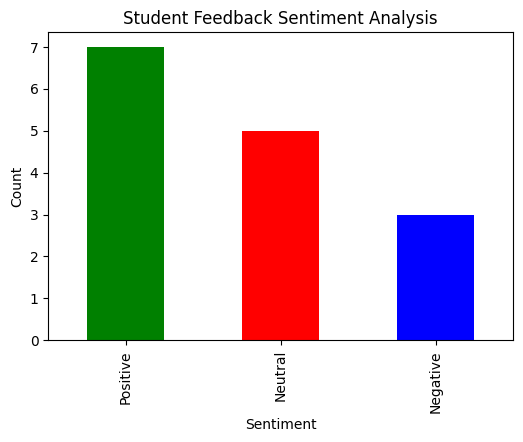

In [9]:
sentiment_count.plot(
    kind="bar",
    color=["green","red","blue"],
    figsize=(6,4)
)

plt.title("Student Feedback Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

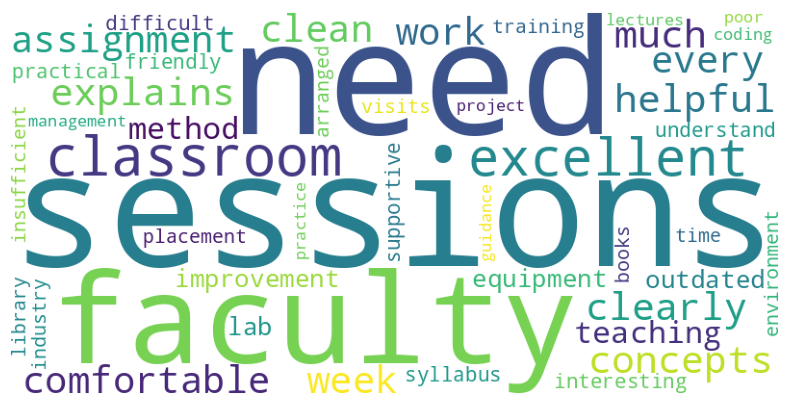

In [10]:
text = " ".join(df["Clean_Feedback"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [11]:
all_words = text.split()

word_freq = pd.Series(all_words).value_counts()

print(word_freq.head(20))

sessions       3
classroom      2
faculty        2
need           2
excellent      2
clearly        1
explains       1
assignment     1
work           1
every          1
week           1
clean          1
helpful        1
much           1
concepts       1
method         1
teaching       1
comfortable    1
lab            1
equipment      1
Name: count, dtype: int64


In [12]:
concerns = [
    "assignment",
    "placement",
    "coding",
    "library",
    "equipment",
    "syllabus",
    "teaching",
    "lecture",
    "lab"
]

for concern in concerns:

    count = df["Clean_Feedback"].str.contains(concern).sum()

    print(concern, ":", count)

assignment : 1
placement : 1
coding : 1
library : 1
equipment : 1
syllabus : 1
teaching : 1
lecture : 1
lab : 2


In [13]:
print("Improvement Suggestions")

print("-----------------------")

print("1. Reduce unnecessary assignment workload.")

print("2. Improve teaching methodology.")

print("3. Upgrade laboratory equipment.")

print("4. Add more placement training programs.")

print("5. Increase library resources.")

print("6. Conduct more coding practice sessions.")

print("7. Arrange industry visits.")

print("8. Improve lecture time management.")

Improvement Suggestions
-----------------------
1. Reduce unnecessary assignment workload.
2. Improve teaching methodology.
3. Upgrade laboratory equipment.
4. Add more placement training programs.
5. Increase library resources.
6. Conduct more coding practice sessions.
7. Arrange industry visits.
8. Improve lecture time management.


In [14]:
print(df)

                                             Feedback  \
0   The faculty explains concepts very clearly and...   
1                Too much assignment work every week.   
2             The classroom is clean and comfortable.   
3                  Teaching method needs improvement.   
4                          Lab equipment is outdated.   
5                Very interesting practical sessions.   
6            The syllabus is difficult to understand.   
7                 Faculty is friendly and supportive.   
8              Need more placement training sessions.   
9                     Library has insufficient books.   
10                   Excellent classroom environment.   
11           More industry visits should be arranged.   
12           Time management during lectures is poor.   
13                    Project guidance was excellent.   
14                Need more coding practice sessions.   

                               Clean_Feedback Sentiment  
0   faculty explains concepts